In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

In [ ]:
class Projectable(ABC):
	"""
	An abstract base class representing a projectable set.

	Methods
	-------
	project(trajectory: Trajectory) -> Trajectory
		Projects the given trajectory onto the set.
	"""

	@abstractmethod
	def project(self, trajectory: Trajectory) -> Trajectory:
		pass

class Network(Projectable):
	"""
	A class representing a network with a given number of nodes and edges.

	Parameters
	----------
	n : int
		Number of nodes in the network.
	m : int
		Number of edges in the network.
	Ybus : numpy.ndarray
		The admittance matrix of the network.
	"""

	def __init__(self, n, m, Ybus):
		self.n = n
		self.m = m
		self.Ybus = Ybus



	def project(self, trajectory: Trajectory) -> Trajectory:
		"""
		Projects the given trajectory onto the network.

		Parameters
		----------
		trajectory : Trajectory
			The trajectory to project.

		Returns
		-------
		Trajectory
			The projected trajectory.
		"""
		

class Trajectory:
	"""
	A class representing a trajectory with time points and corresponding states.

	Parameters
	----------
	T : int
		Time horizon of the trajectory.
	vars: dict
		A dictionary mapping variable names to their dimensions.
	"""

	def __init__(self, T: int, vars: dict):
		self.T = T
		self.vars = vars
		self.q = sum(vars.values())
		self.w = np.zeros((T, self.q), dtype=np.complex64)

	def get_variable_indices(self, var_name: str) -> slice:
		"""
		Returns the slice indices for the given variable name.

		Parameters
		----------
		var_name : str
			The name of the variable to get indices for.

		Returns
		-------
		slice
			The slice object representing the indices of the variable in the trajectory.
		"""
		
		start_index = 0
		for key, size in self.vars.items():
			if key == var_name:
				return slice(start_index, start_index + size)
			start_index += size
		
		raise ValueError(f"Variable '{var_name}' not found in trajectory.")
	
	def get_subtrajectory(self, var_name: str) -> np.ndarray:
		"""
		Returns the subtrajectory corresponding to the given variable name.
		
		Parameters
		----------
		var_name : str
			The name of the variable to extract.
		"""

		return self.w[:, ]

	def __add__(self, other):
		if not isinstance(other, Trajectory):
			return NotImplemented
		if self.T != other.T or self.q != other.q:
			raise ValueError("Trajectories must have the same dimensions for addition.")
		result = Trajectory(self.T, self.vars)
		result.w = self.w + other.w
		return result
	
	def __sub__(self, other):
		if not isinstance(other, Trajectory):
			return NotImplemented
		if self.T != other.T or self.q != other.q:
			raise ValueError("Trajectories must have the same dimensions for subtraction.")
		result = Trajectory(self.T, self.vars)
		result.w = self.w - other.w
		return result
	
	def norm(self):
		return np.linalg.norm(self.w)

def dykstra(sets: list[Projectable], x0: Trajectory, threshold=1e-6, max_iterations=1000) -> Trajectory:
	increments = []
	for _ in sets:
		increments.append(Trajectory(x0.T, x0.vars))

	current_x = x0
	
	for iteration in range(max_iterations):
		x_start_of_cycle = current_x

		for i, p_set in enumerate(sets):
			# 1. Add the increment to the current point
			w = current_x + increments[i]

			# 2. Project onto the current set
			projected_x = p_set.project(w)

			# 3. Update the increment for this specific set
			increments[i] = w - projected_x

			# 4. Update the current state
			current_x = projected_x

		# 5. Check for convergence
		diff = current_x - x_start_of_cycle

		# print(f"Iteration {iteration + 1}: Norm of difference = {diff.norm()}")
		
		if diff.norm() < threshold:
			break

	return current_x



In [3]:
# Main optimization loop

n = 6
m = 5

vars = {
	"current": n,
	"voltage": n,
	"flow": m,
	"effort": m
}

num_iters = 100
T = 10

traj = Trajectory(T, vars)
network = Network(n, m)


Iteration 1: Norm of difference = 0.5627774222552397
Iteration 2: Norm of difference = 0.041329416600019264
Iteration 3: Norm of difference = 0.01233073707278619
Iteration 4: Norm of difference = 0.004111489580321695
Iteration 5: Norm of difference = 0.001416960735090123
Iteration 6: Norm of difference = 0.0004937354472151647
Iteration 7: Norm of difference = 0.00017269376281726505
Iteration 8: Norm of difference = 6.0482870633440757e-05
Iteration 9: Norm of difference = 2.119281683084962e-05
Iteration 10: Norm of difference = 7.427030542894617e-06
Iteration 11: Norm of difference = 2.6029531141548824e-06
Iteration 12: Norm of difference = 9.122756974132277e-07


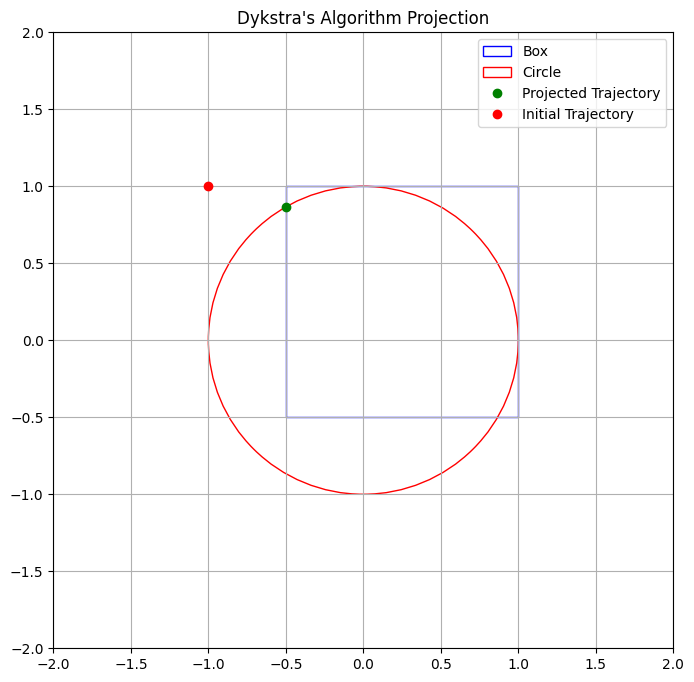

In [5]:
# Testing
class Circle(Projectable):
	def __init__(self, radius):
		self.radius = radius

	def project(self, trajectory: Trajectory) -> Trajectory:
		# Simple projection onto a circle of given radius
		norm = trajectory.norm()
		if norm > self.radius:
			projected_traj = Trajectory(trajectory.T, trajectory.vars)
			projected_traj.w = (trajectory.w / norm) * self.radius
			return projected_traj
		else:
			return trajectory

class Box(Projectable):
	def __init__(self, lower_bound, upper_bound):
		self.lower_bound = lower_bound
		self.upper_bound = upper_bound

	def project(self, trajectory: Trajectory) -> Trajectory:
		# Simple projection onto a box defined by lower and upper bounds
		projected_traj = Trajectory(trajectory.T, trajectory.vars)
		projected_traj.w = np.clip(trajectory.w, self.lower_bound, self.upper_bound)
		return projected_traj

a = -0.5
b = 1.0
b1 = Box(a, b)
c1 = Circle(1)

sets = [b1, c1]
x0 = Trajectory(1, {"var1": 1, "var2": 1})
x0.w = np.array([-1.0, 1.0])  # Starting point outside both sets

result = dykstra(sets, x0)

import matplotlib.patches as patches

# Visualization
# Plot the trajectory and the sets for visualization
fig, axs = plt.subplots(1, 1, figsize=(8, 8))
axs.set_title("Dykstra's Algorithm Projection")
axs.set_xlim(-2, 2)
axs.set_ylim(-2, 2)
# Plot the box
box = patches.Rectangle((a, a), b - a, b - a, fill=False,
					edgecolor='blue', label='Box')
axs.add_patch(box)
# Plot the circle
circle = patches.Circle((0, 0), 1, fill=False,
					edgecolor='red', label='Circle')
axs.add_patch(circle)
# Plot the trajectory
axs.plot(result.w[0], result.w[1], 'go', label='Projected Trajectory')
axs.plot(x0.w[0], x0.w[1], 'ro', label='Initial Trajectory')
axs.legend()
plt.grid()

